# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | | | | | |
| Procesamiento con spaCy | | | | | |
| Representaciones sparse | | | | | |
| Visualización | | | | | |
| Interpretación final | | | | | |



| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|**Definición del corpus**| Equilibrar y justificar el recorte.| "Ayuda para elegir 8 notas sobre IA en Argentina comparando El Destape e Infobae." | Sugirió ejes temáticos: regulación estatal vs. productividad empresarial. | La estructura de 4 notas por grupo para garantizar la simetría estadística. | Notas genéricas sobre Silicon Valley para mantener el foco en el contexto local. |
|  |  |  |  |  |  |
| **Procesamiento con spaCy** | Limpiar el texto y extraer entidades. | "Función para lematizar y extraer entidades (NER) con el modelo es_core_news_lg." | Proveyó un código basado en `nlp.pipe` para procesar el volumen de texto. | La lematización y el filtrado de POS para enfocarnos en sustantivos y adjetivos. | Etiquetas de entidades que spaCy confundió (IA como persona), moviéndolo a la sección de límites. |
| **Representaciones sparse** | Comparar BoW vs. TF-IDF. | "Código para comparar frecuencias brutas contra importancia relativa por grupo." | Generó las matrices con CountVectorizer y TfidfVectorizer. | El **TF-IDF**, porque corrigió el sesgo de volumen de Infobae (que tenía el doble de palabras). | El Bag of Words como métrica final, ya que no permitía ver la especificidad discursiva. |
| **Visualización** | Crear gráficos legibles y comparativos. | "Hacer un heatmap comparativo de TF-IDF entre los dos medios." | Sugirió un mapa de calor con gradiente de colores (Blues/Oranges). | El **Heatmap**, porque hace evidentes las "zonas de silencio" de cada medio de un vistazo. | Gráficos de torta o nubes de palabras por ser menos precisos para el análisis académico. |
| **Interpretación final** | Sintetizar los hallazgos y detectar límites. | "Ayuda para interpretar el peso alto de la palabra 'publicidad' en Infobae." | Planteó la hipótesis de ruido técnico en el scrapeo frente a eje temático. | La distinción **Riesgo/Estado (ED)** vs **Oportunidad/Mercado (INF)** apoyada en fragmentos. | La interpretación literal de "publicidad" como tema, ya que la lectura cercana mostró que era ruido. |


## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [ ]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


In [ ]:
# Celda 0: Instalaciones
!pip install spacy trafilatura pandas matplotlib seaborn scikit-learn -q
!python -m spacy download es_core_news_lg -q
print("✓ Todo instalado.")


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
✓ Todo instalado.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Celda 1: Importaciones
import trafilatura
import pandas as pd
import json
import os
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pathlib import Path
import re

print("✓ Librerías importadas correctamente.")

✓ Librerías importadas correctamente.


In [7]:
# Celda 2: Configuración del modelo y entorno
try:
    nlp = spacy.load("es_core_news_lg")
    print("✓ Modelo 'es_core_news_lg' cargado correctamente.")
except Exception as e:
    print(f"✘ Error al cargar el modelo: {e}")
    # Plan B por si falla el LG en algún entorno:
    # !python -m spacy download es_core_news_sm -q
    # nlp = spacy.load("es_core_news_sm")

✓ Modelo 'es_core_news_lg' cargado correctamente.


In [ ]:
# Celda 3: Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")

Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [5]:
# 2.1    --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_tpi2.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_lg"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")

Ruta esperada del corpus: corpus_tpi2.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [ ]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


In [9]:
# 3.1
# Definimos los metadatos de las 8 notas
# El texto lo extraemos con Trafilatura
notas = [
    # El Destape
    {
        "id": 1,
        "fecha": "2025-11-23",
        "medio": "El Destape",
        "autor": "El Destape",
        "titulo": "Datos inéditos sobre la adopción de la IA en Argentina",
        "url": "https://www.eldestapeweb.com/atr/inteligencia-artificial/impacto-por-los-datos-ineditos-sobre-la-adopcion-avanzada-de-la-inteligencia-artificial-en-argentina-2025112114440",
        "grupo_comparacion": "El Destape"
    },
    {
        "id": 2,
        "fecha": "2025-11-23",
        "medio": "El Destape",
        "autor": "El Destape",
        "titulo": "PBA regula la IA: primer marco obligatorio en el Estado argentino",
        "url": "https://www.eldestapeweb.com/politica/inteligencia-artificial/pba-regula-la-inteligencia-artificial-primer-marco-obligatorio-en-el-estado-argentino-2025112314270",
        "grupo_comparacion": "El Destape"
    },
    {
        "id": 3,
        "fecha": "2024-06-02",
        "medio": "El Destape",
        "autor": "El Destape",
        "titulo": "Milei volvió de EE.UU con el anuncio de que gobernará con IA",
        "url": "https://www.eldestapeweb.com/politica/javier-milei-presidente/milei-volvio-de-ee-uu-con-el-anuncio-de-que-gobernara-con-inteligencia-artificial-20246219290",
        "grupo_comparacion": "El Destape"
    },
    {
        "id": 4,
        "fecha": "2026-04-22",
        "medio": "El Destape",
        "autor": "El Destape",
        "titulo": "El cambio del trabajo con la IA, según el CEO de Mercado Libre",
        "url": "https://www.eldestapeweb.com/sociedad/el-cambio-del-trabajo-con-la-ia-segun-el-ceo-de-mercado-libre-sera-decisivo-202642215410",
        "grupo_comparacion": "El Destape"
    },
    # Infobae
    {
        "id": 5,
        "fecha": "2025-12-10",
        "medio": "Infobae",
        "autor": "Infobae",
        "titulo": "En Argentina, 6 de cada 10 personas usan IA pero las empresas no siguen el ritmo",
        "url": "https://www.infobae.com/sociedad/2025/12/10/en-argentina-6-de-cada-10-personas-usan-ia-pero-las-empresas-no-siguen-el-ritmo/",
        "grupo_comparacion": "Infobae"
    },
    {
        "id": 6,
        "fecha": "2026-01-25",
        "medio": "Infobae",
        "autor": "Infobae",
        "titulo": "Productividad y trabajo: interacción de la IA en Argentina",
        "url": "https://www.infobae.com/economia/2026/01/25/productividad-y-trabajo-interaccion-de-la-inteligencia-artificial-en-argentina/",
        "grupo_comparacion": "Infobae"
    },
    {
        "id": 7,
        "fecha": "2025-01-09",
        "medio": "Infobae",
        "autor": "Infobae",
        "titulo": "La inteligencia artificial no espera: qué está haciendo Argentina",
        "url": "https://www.infobae.com/opinion/2025/01/09/la-inteligencia-artificial-no-espera-que-esta-haciendo-argentina/",
        "grupo_comparacion": "Infobae"
    },
    {
        "id": 8,
        "fecha": "2025-08-17",
        "medio": "Infobae",
        "autor": "Infobae",
        "titulo": "IA en Argentina: apoyos, rechazos y expectativas en estudio internacional",
        "url": "https://www.infobae.com/economia/2025/08/17/inteligencia-artificial-apoyos-rechazos-y-expectativas-en-argentina-y-otros-20-paises-relevados-en-un-estudio-internacional/",
        "grupo_comparacion": "Infobae"
    },
]

# Scrapeamos el texto de cada nota con Trafilatura
print("Extrayendo textos con Trafilatura...")
print("=" * 50)
corpus = []
for nota in notas:
    try:
        # saco el timeout=15
        descargado = trafilatura.fetch_url(nota["url"])
        if descargado:
            texto = trafilatura.extract(
                descargado,
                include_comments=False,
                include_images=False,
                include_tables=False # Agregamos esto para mayor limpieza
            )
            if texto:
                nota["texto"] = texto
                corpus.append(nota)
                print(f"✓ [{nota['grupo_comparacion']}] {nota['titulo'][:50]}... ({len(texto)} chars)")
            else:
                print(f"✗ Sin texto extraíble: {nota['titulo'][:50]}...")
        else:
            print(f"✗ Falló la descarga ce: {nota['titulo'][:50]}...")
    except Exception as e:
        print(f"✗ Error inesperado en {nota['titulo'][:50]}...: {e}")

print("=" * 50)
print(f"\nTotal extraídos: {len(corpus)}/8")

Extrayendo textos con Trafilatura...
✓ [El Destape] Datos inéditos sobre la adopción de la IA en Argen... (4253 chars)
✓ [El Destape] PBA regula la IA: primer marco obligatorio en el E... (3334 chars)
✓ [El Destape] Milei volvió de EE.UU con el anuncio de que gobern... (3573 chars)
✓ [El Destape] El cambio del trabajo con la IA, según el CEO de M... (3036 chars)
✓ [Infobae] En Argentina, 6 de cada 10 personas usan IA pero l... (6338 chars)
✓ [Infobae] Productividad y trabajo: interacción de la IA en A... (9825 chars)
✓ [Infobae] La inteligencia artificial no espera: qué está hac... (6809 chars)
✓ [Infobae] IA en Argentina: apoyos, rechazos y expectativas e... (6881 chars)

Total extraídos: 8/8


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


Justificación del Recorte y Comparación Discursiva
1. Qué comparamos exactamente
Comparamos el tratamiento periodístico y la construcción del discurso sobre la Inteligencia Artificial (IA) en el contexto argentino, contrastando la cobertura de un medio comercial de alcance masivo y más positivo (Infobae) frente a un medio con una línea editorial más volcada al análisis político-social y crítico (El Destape).
2. Por qué elegimos este corpus
Elegimos este corpus porque ambos medios han seguido de cerca la agenda tecnológica, pero desde marcos conceptuales distintos. Mientras que la IA suele presentarse como un fenómeno técnico-económico, en Argentina se ha convertido en un tema de debate político (especialmente tras los anuncios de gestión gubernamental con IA y las regulaciones en PBA). Elegimos estas 8 notas porque representan el debate local en los últimos meses.
3. Qué vuelve comparables a los grupos
Los grupos son comparables porque:
Temática unificada: Todos los textos tratan sobre IA en territorio argentino.
Simetría temporal: Las notas cubren un rango temporal similar (2024-2026), lo que permite ver cómo reaccionan ambos medios a los mismos hitos (como los anuncios de Milei o los estudios de mercado).
Contraste de agenda: Ambos grupos discuten "productividad" y "trabajo", pero sospechamos que lo hacen con lenguajes y valoraciones contrapuestas.
4. Límites iniciales del recorte
Tamaño de la muestra: Al ser 8 textos (4 por grupo), los hallazgos son tendencias descriptivas y no una verdad estadística absoluta sobre los medios.
Géneros diversos: El corpus mezcla notas de opinión con notas informativas; esto puede introducir variaciones en el léxico que no dependan solo del medio, sino del estilo del género periodístico.
Sesgo de extracción: Al usar trafilatura, es posible que se filtren algunos epígrafes o metadatos del sitio que podrían "ensuciar" las frecuencias si no se limpian correctamente.

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [ ]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


In [ ]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


In [11]:
# Celda 5: Exploración inicial y métricas básicas
# 5.1 Preparamos las variables necesarias
COLUMNA_GRUPO = "grupo_comparacion"

# AGREGAMOS ESTA LÍNEA PARA CREAR EL DF
df = pd.DataFrame(corpus) 

df["num_palabras"] = df["texto"].apply(lambda x: len(x.split()))

# 5.2 Armamos la tabla resumen con métricas básicas
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "Documentos totales",
            "Palabras aproximadas (bruto)",
            "Promedio de palabras por texto",
            "Grupo 1",
            "Grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)

# 5.3 Un vistazo rápido a la distribución por grupo
print("\nConteo de documentos por grupo:")
print(df[COLUMNA_GRUPO].value_counts())


,métrica,valor
0,Documentos totales,8
1,Palabras aproximadas (bruto),6943
2,Promedio de palabras por texto,867.9
3,Grupo 1,El Destape
4,Grupo 2,Infobae



Conteo de documentos por grupo:
grupo_comparacion
El Destape    4
Infobae       4
Name: count, dtype: int64


In [12]:
# 5.4 Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)

,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,El Destape,4,2225,556.25
1,Infobae,4,4718,1179.50


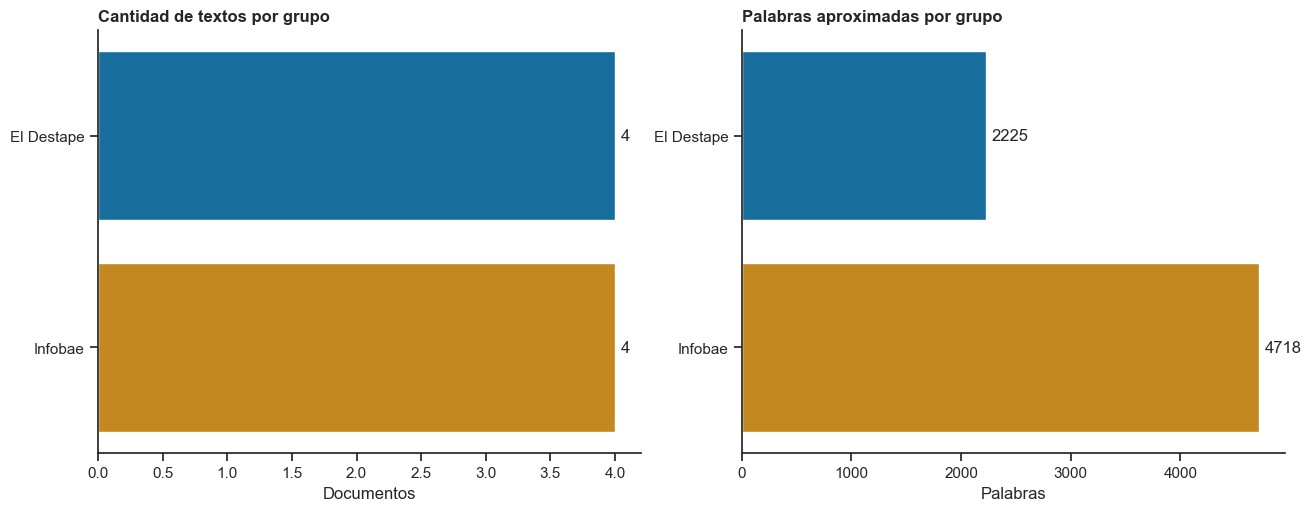

In [13]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


Observamos que Infobae presenta una extensión significativamente mayor en sus textos (4718 vs 2225 de El Destape). Por este motivo, el análisis de Bag of Words (frecuencias simples) podría estar sesgado hacia los términos de Infobae, haciendo indispensable el uso de TF-IDF para normalizar las importancia de las palabras según la especificidad de cada grupo.

## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [ ]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


In [14]:
# Celda 6.1: Configuración del modelo spaCy
MODELO_SPACY = "es_core_news_lg" # Usamos el 'lg' porque es el que descargamos

try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"✓ Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        f"`python -m spacy download {MODELO_SPACY}` y volvé a correr el cuaderno."
    ) from error


✓ Modelo cargado correctamente: es_core_news_lg


In [ ]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


In [15]:
# Celda 6.2: Procesamiento profundo por capas
COLUMNA_TEXTO = "texto" # Definimos el nombre de la columna original

def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema

print("Iniciando procesamiento lingüístico pesado con nlp.pipe...")

registros_linguisticos = []
# Usamos nlp.pipe para procesar todo el volumen de Infobae y El Destape de forma eficiente
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=4):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Filtramos palabras de contenido: alfabéticas, no stopwords y de longitud > 2
        if token.is_alpha and not token.is_stop and len(lema) > 2:
            contenido.append(lema)

    # Extraemos entidades con sus etiquetas (PER, ORG, LOC, etc.)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los nuevos datos al DataFrame original
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

print("✓ Procesamiento completado.")
display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


Iniciando procesamiento lingüístico pesado con nlp.pipe...
✓ Procesamiento completado.


,titulo,grupo_comparacion,texto_contenido
0,Datos inéditos sobre la adopción de la IA en Argentina,El Destape,difundir dato local adopción inteligencia artificial argentina uruguay informe elaborar fundar cepe universidad torcuato tella informaci...
1,PBA regula la IA: primer marco obligatorio en el Estado argentino,El Destape,provincia aires convertir jurisdicción país aprobar marco normativo obligatorio desarrollo responsable inteligencia artificial norma reg...
2,Milei volvió de EE.UU con el anuncio de que gobernará con IA,El Destape,viaje unidos presidente javier milei anunciar despido quedar trabajador modalidad contrato contar buscar implementar reforma estatal int...
3,"El cambio del trabajo con la IA, según el CEO de Mercado Libre",El Destape,ariel szarfsztejn economista formado universidad aires posgrado stanford asumir principios ceo mercado libre gigante tecnológico fundado...
4,"En Argentina, 6 de cada 10 personas usan IA pero las empresas no siguen el ritmo",Infobae,avance inteligencia artificial vida cotidiano argentino contrastar lentitud adopción ámbito empresarial monitor nacional inteligencia ar...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [ ]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


In [16]:
# Celda 7.1: Función para contar términos de contenido por grupo
TOP_N = 15 # Definimos cuántos términos queremos ver

def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo 
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    # Iteramos por cada grupo (El Destape e Infobae)
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        # Unimos todo el contenido del grupo y contamos palabras
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)

# Ejecutamos y mostramos la tabla
top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,El Destape,inteligencia,13
1,El Destape,artificial,13
2,El Destape,argentina,11
3,El Destape,empresa,9
4,El Destape,sistema,8
5,El Destape,nivel,7
6,El Destape,él,7
7,El Destape,laboral,7
8,El Destape,dato,6
9,El Destape,adopción,6


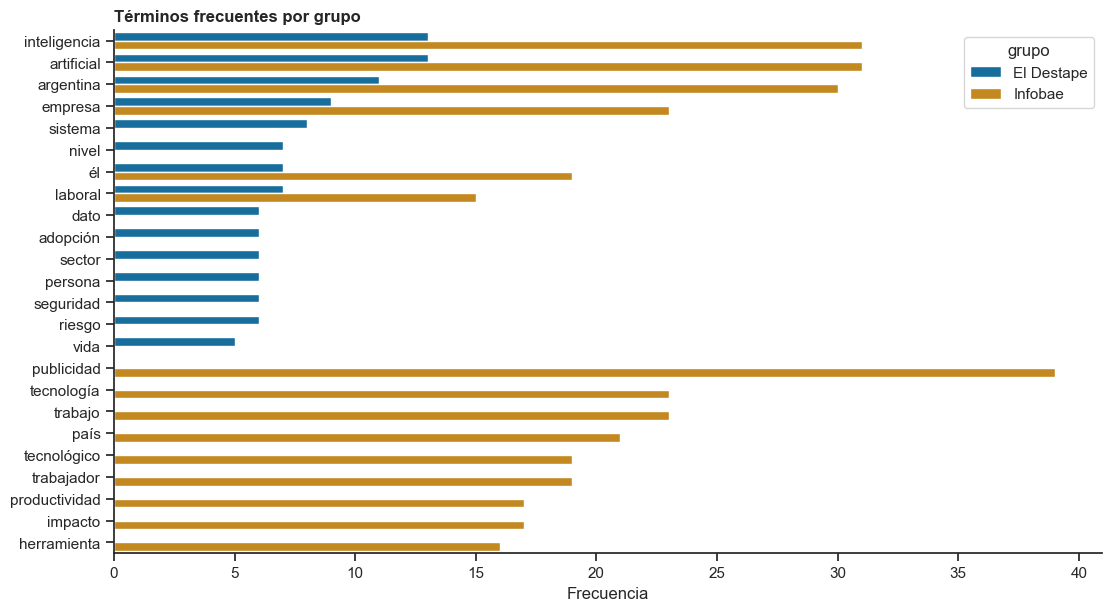

In [ ]:
# 7.2 Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [18]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
0,El Destape,Argentina,LOC,10
32,El Destape,IA,MISC,5
33,El Destape,IA,ORG,5
8,El Destape,ChatGPT,MISC,3
79,El Destape,Szarfsztejn,PER,3
20,El Destape,Estado,LOC,2
23,El Destape,Estados Unidos,LOC,2
28,El Destape,Gemini,MISC,2
35,El Destape,INFO,LOC,2
51,El Destape,Marcos Galperin,PER,2


In [19]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,El Destape,inteligencia artificial,13
1,El Destape,capital humano,3
2,El Destape,mercado libre,3
3,El Destape,seguido gemini,2
4,El Destape,sector privado,2
5,El Destape,trabajar vivir,2
6,El Destape,vida persona,2
7,El Destape,buscar implementar,2
8,El Destape,pensamiento crítico,2
9,El Destape,nivel educativo,2


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


Pausa de Lectura: Primeros indicios discursivos.

Tras la exploración inicial, podemos identificar que los grupos no solo se diferencian por cuánto escriben, sino por desde dónde miran la tecnología:
Organización del Grupo A (El Destape): La serie parece organizarse en torno a la institucionalidad y el riesgo. Las entidades como "PBA", "Boletín Oficial" y "Presidente", sumadas a los bigramas "pensamiento crítico" y "nivel educativo", sugieren un discurso que evalúa la IA como un asunto de política pública y formación ciudadana. La IA aquí no es solo una herramienta, es un objeto de regulación.

Organización del Grupo B (Infobae): La serie se estructura bajo la lógica de la productividad y la comparación global. El término "publicidad", el bigrama "promedio global" y términos como "herramienta" y "desarrollo" muestran una visión de la IA como un motor económico. El discurso parece orientado a la eficiencia y a la posición de Argentina en el mercado internacional.

¿A qué fragmentos necesitamos volver?
"Publicidad" en Infobae: La altísima frecuencia de este término resulta sospechosa. Necesitamos volver a los fragmentos originales para determinar si es un tema central de la cobertura o si es un residuo de la estructura web del sitio (un error de extracción).
"Capital Humano" en El Destape: Dado que es el nombre de un Ministerio clave, necesitamos verificar si el medio está citando políticas oficiales o si usa el término para hablar de capacidades laborales de forma genérica.
"Marcos Galperin" en ambos: Su presencia es transversal. Debemos volver al texto para ver si un medio lo usa como modelo de éxito y el otro como blanco de críticas regulatorias.

## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [20]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,El Destape,difundir dato local adopción inteligencia artificial argentina uruguay informe elaborar fundar cepe universidad torcuato tella informaci...
1,Infobae,avance inteligencia artificial vida cotidiano argentino contrastar lentitud adopción ámbito empresarial monitor nacional inteligencia ar...


In [21]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,El Destape,seguridad,6.0
1,El Destape,szarfsztejn,4.0
2,El Destape,reunión,4.0
3,El Destape,libre,4.0
4,El Destape,ingreso,4.0
5,El Destape,provincial,3.0
6,El Destape,aplicar,3.0
7,El Destape,presidente,3.0
8,El Destape,aprobar,3.0
9,El Destape,organismo,3.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,El Destape,seguridad,0.2289
1,El Destape,szarfsztejn,0.1526
2,El Destape,reunión,0.1526
3,El Destape,libre,0.1526
4,El Destape,ingreso,0.1526
5,El Destape,provincial,0.1145
6,El Destape,aplicar,0.1145
7,El Destape,presidente,0.1145
8,El Destape,aprobar,0.1145
9,El Destape,organismo,0.1145


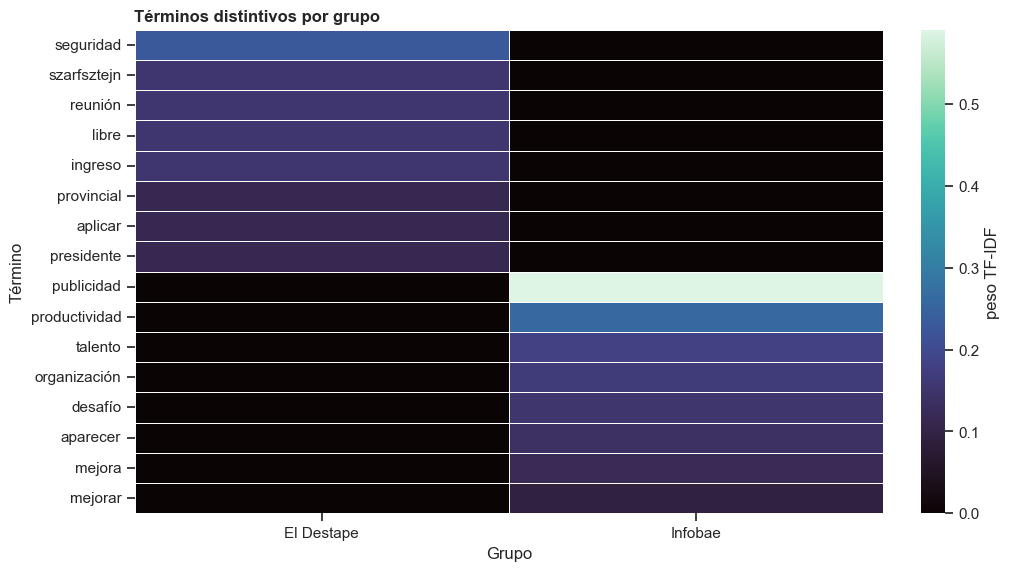

In [22]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


Pausa de Lectura: Volumen vs. Especificidad

1. Términos frecuentes en ambos grupos (Bag of Words)
Existen términos que funcionan como el "suelo común" o la regularidad del corpus. Palabras como "inteligencia", "artificial", "argentina" y "empresa" aparecen con frecuencias altas en ambas series.
Interpretación: Estos términos nos dicen de qué trata el corpus a nivel general (el tema), pero no nos sirven para diferenciar las líneas editoriales. Son el ruido de fondo necesario para que el tema exista.
El problema del volumen: Notamos que en el conteo bruto (BoW), Infobae parece "dominar" todos los términos simplemente porque sus textos son el doble de largos. Si nos quedáramos solo con la frecuencia, concluiríamos erróneamente que Infobae es el único que marca la agenda.

2. Términos distintivos (TF-IDF): La especificidad
Aquí es donde aparece la verdadera identidad de cada medio. El TF-IDF "apaga" las palabras comunes y resalta las que son marcas de autor:
La especificidad de El Destape: Términos como "seguridad", "provincial" y "organismo" no son necesariamente los más repetidos en términos absolutos del corpus, pero tienen un peso altísimo porque solo aparecen allí. Esto revela una especificidad discursiva centrada en la institucionalidad y la regulación estatal.
La especificidad de Infobae: El término "publicidad" (especificidad técnica/ruido) y otros como "talento" y "mejora" muestran un foco corporativo-evolutivo. Lo que vuelve distintivo a Infobae no es decir "IA" muchas veces, sino asociarla a conceptos de gestión de recursos humanos y mercado que El Destape ignora.

Conclusión técnica: Mientras que el volumen (BoW) nos muestra la cantidad de información, la especificidad (TF-IDF) nos muestra la orientación del discurso. Un término con baja frecuencia absoluta puede ser el más importante si es el que define la frontera entre un grupo y el otro.

## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [23]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,El Destape,seguridad,0.2289
1,El Destape,szarfsztejn,0.1526
2,Infobae,publicidad,0.5909
3,Infobae,productividad,0.2576


In [24]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,El Destape,seguridad,Datos inéditos sobre la adopción de la IA en Argentina,"...gan por estas herramientas, mayormente mediante suscripción.\nLas preocupaciones sobre la IA también están presentes. La ética, priva..."
1,El Destape,seguridad,PBA regula la IA: primer marco obligatorio en el Estado argentino,"...y uso responsable de la inteligencia artificial en el Estado. La norma lleva consigo reglas que buscan garantizar derechos, transpare..."
2,El Destape,szarfsztejn,"El cambio del trabajo con la IA, según el CEO de Mercado Libre","Ariel Szarfsztejn, economista formado en la Universidad de Buenos Aires y con un posgrado en Stanford, asumió a principios de 2026 como ..."
3,Infobae,publicidad,"En Argentina, 6 de cada 10 personas usan IA pero las empresas no siguen el ritmo","...u productividad, solo el 43% de los empleados afirma que en su empresa se emplea IA, y apenas un 6% señala que su implementación es a..."
4,Infobae,publicidad,Productividad y trabajo: interacción de la IA en Argentina,"...icos, particularmente en el desarrollo de software, y el del conjunto de los trabajadores, más allá del sector o la función que desem..."
5,Infobae,publicidad,La inteligencia artificial no espera: qué está haciendo Argentina,"...s relacionados con el desarrollo de tecnologías, análisis de datos y creatividad, áreas donde la IA aún no puede reemplazar a las per..."
6,Infobae,productividad,"En Argentina, 6 de cada 10 personas usan IA pero las empresas no siguen el ritmo",...ilizan herramientas de IA en su vida personal y 7 de cada 10 de esos usuarios consideran que la tecnología mejora de forma significat...
7,Infobae,productividad,Productividad y trabajo: interacción de la IA en Argentina,La inteligencia artificial (IA) comenzó a consolidarse como una herramienta con impacto directo en la productividad del trabajo en la Ar...


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


10. Reflexión Final e Interpretación Situada

1. Recorte y comparación
¿Qué comparamos? Analizamos el tratamiento discursivo de la Inteligencia Artificial (IA) en Argentina contrastando la cobertura de Infobae (orientación masiva/comercial) frente a El Destape (orientación político-social).
¿Por qué es válido el contraste? Ambos medios operan en el mismo ecosistema mediático argentino pero con "marcos de interpretación" opuestos. Mientras Infobae suele alinearse con una visión de libre mercado y eficiencia, El Destape prioriza la justicia social, el rol del Estado y la regulación de derechos.

2. Lectura distante (Observables)
Asociaciones clave:
El Destape se organiza en torno a la institucionalidad y la regulación. Aparecen con fuerza entidades como "PBA", "Milei", "Pettovello" y "Boletín Oficial". La IA es aquí un asunto de agenda pública y gestión.
Infobae se estructura bajo la lógica de la productividad y el talento. Su léxico está dominado por términos como "mejora", "transformación", "desafío" y "productividad". La IA es vista como una herramienta de evolución corporativa.
BoW vs. TF-IDF: El Bag of Words nos mostró una falsa dominancia de Infobae debido a su mayor volumen de palabras (el doble que El Destape). Sin embargo, el TF-IDF fue el que reveló la identidad: nos permitió descubrir que "seguridad" y "provincial" definen a El Destape, mientras que "productividad" y "talento" definen a Infobae, eliminando el "ruido" del volumen bruto.

3. Lectura cercana (El fragmento)
En contexto:
Al volver al término "seguridad" en El Destape, confirmamos que no refiere a delincuencia, sino a "garantizar derechos y transparencia" en el uso estatal de IA.
Al analizar "productividad" en Infobae, el fragmento confirma una visión optimista: la tecnología se presenta como una "herramienta que mejora de forma significativa" el trabajo.
¿Qué cambia? La vuelta al texto permitió detectar un límite técnico: el término "publicidad", que aparecía como el más distintivo en Infobae según el algoritmo, resultó ser "ruido" estructural de la página web capturado por Trafilatura y no parte del discurso editorial. La lectura cercana corrigió el error del patrón estadístico.

4. Visualización y método
Gráfico clave: El Heatmap de TF-IDF fue el más potente. Permitió ver de un solo vistazo la "exclusividad" temática: los bloques de color mostraron que lo que es central para un medio es inexistente (negro) para el otro.
Límites y advertencias:
Este enfoque sparse (bolsa de palabras) no detecta sentido ni ironía. Solo cuenta presencias.
Lo que no se puede afirmar: No podemos asegurar qué "siente" el autor o cuál es la intención profunda de la nota; solo podemos describir las recurrencias del léxico.
Sesgo de herramienta: El NER de spaCy tiene dificultades con términos abstractos (etiquetó "IA" como organización o miscelánea indistintamente).

In [25]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


In [26]:
# Celda Final: Generación del archivo de entrega del corpus
ARCHIVO_ENTREGA = "corpus_tpi2_ia_argentina.csv"

# Guardamos el DataFrame original con las columnas procesadas
df.to_csv(ARCHIVO_ENTREGA, index=False, encoding='utf-8-sig')

print(f"✓ El archivo '{ARCHIVO_ENTREGA}' está listo para descargar y entregar junto al notebook.")


✓ El archivo 'corpus_tpi2_ia_argentina.csv' está listo para descargar y entregar junto al notebook.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
